In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv('roll_rate_results.csv')

In [3]:
clean_quarters = df['quarter']
df['date'] = pd.PeriodIndex(clean_quarters, freq='Q').to_timestamp()

C:\Users\agraw\AppData\Local\Temp\ipykernel_23384\1604720720.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=12)


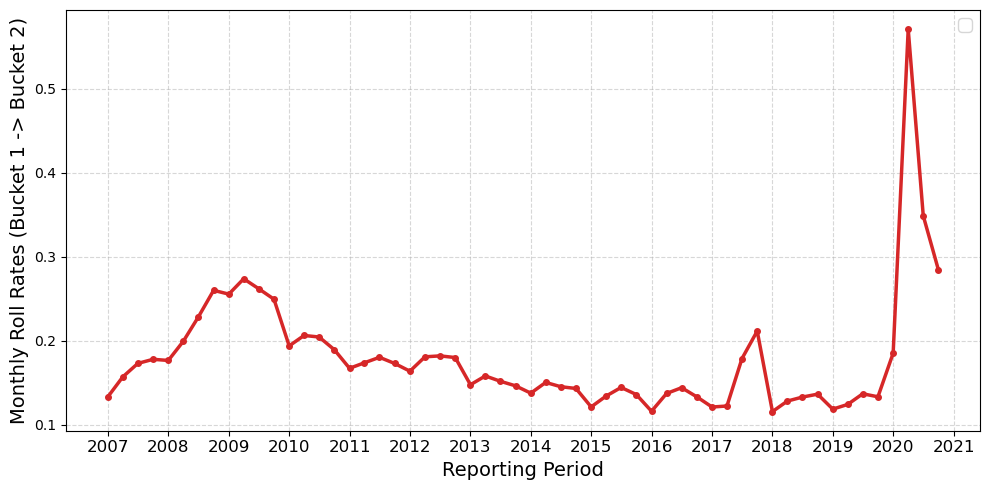

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['date'], df['actual_rr'], color='#d62728', linewidth=2.5, marker='o', markersize=4)
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=12, rotation=0)

ax.set_ylabel('Monthly Roll Rates (Bucket 1 -> Bucket 2)', fontsize=14)
ax.set_xlabel('Reporting Period', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=12)


plt.tight_layout()
plt.show()

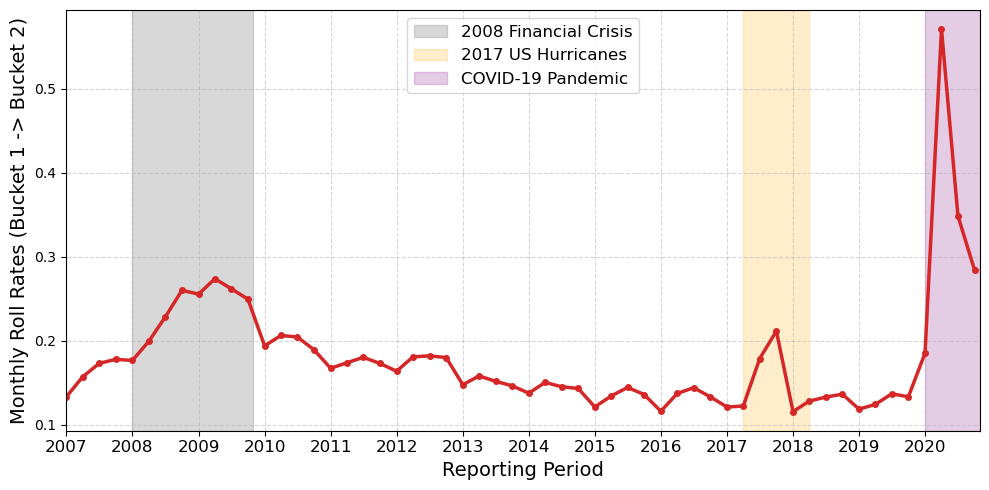

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['date'], df['actual_rr'], color='#d62728', linewidth=2.5, marker='o', markersize=4)
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.set_xlim(df['date'].min(), df['date'].max() + pd.DateOffset(days=30))

ax.axvspan(pd.to_datetime('2008-01-01'), pd.to_datetime('2009-10-31'), color='gray', alpha=0.3, label='2008 Financial Crisis')
ax.axvspan(pd.to_datetime('2017-04-01'), pd.to_datetime('2018-03-31'), color='orange', alpha=0.2, label='2017 US Hurricanes')
ax.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2020-10-30'), color='purple', alpha=0.2, label='COVID-19 Pandemic')

ax.set_ylabel('Monthly Roll Rates (Bucket 1 -> Bucket 2)', fontsize=14)
ax.set_xlabel('Reporting Period', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=12)


plt.tight_layout()
plt.savefig('roll_rates.png', dpi=300)
plt.show()